# Declaring an experiment: one interface, three kinds of traffic

An experiment here is a **declaration**, not a script. You say what is held and what varies, hand
it a backend, and get one row per condition. What this notebook is about is the piece that makes
the declaration cover more than a pair of aircraft: the **scenario**.

Three families of study live in this project, and they differ in exactly one thing — how a seed
becomes a fleet:

| | what varies | what it answers |
|---|---|---|
| **pairwise** | crossing angle, miss distance, side | how does the algorithm behave *as a geometry changes* |
| **ring** | fleet size | what does uncertainty do to *one arranged worst case* |
| **random traffic** | fleet size, disc radius | what happens *on average over the arrangements that occur* |

Everything downstream — the rules, the estimators, the caching, the reporting — is shared. So a
scenario is one object with one required method, and swapping it is the whole difference between
those three studies.

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr import (
    M600,
    MVP,
    VO,
    CrossingRing,
    Fixed,
    GnssNavigation,
    Ladder,
    Methods,
    PairwiseEncounter,
    PastCPA,
    ProbabilisticFTR,
    RandomTraffic,
    StateBased,
    Sweep,
    run_experiment,
)
from opencdarr.config import (
    Config,
    ConflictConfig,
    MethodsConfig,
    ScenarioConfig,
    SimulationConfig,
)
from opencdarr.experiment import IPS, MC

# The base config supplies everything no axis declares: the encounter distribution's parameters,
# the protected zone and horizon, and the numerics. Anything declared Fixed or Sweep overrides it.
CFG = Config(
    seed=0,
    n_encounters=0,          # set by the backend
    scenario=ScenarioConfig(aircraft_type="M600", speed=10.0, dcpa_max=50.0, tlos=60.0,
                            pos_ci95=10.0, vel_ci95=1.0),     # a 10 m / 1 m/s GNSS fix
    conflict=ConflictConfig(rpz=50.0, t_lookahead=30.0),
    methods=MethodsConfig(detection="statebased", resolution="mvp", recovery="pastcpa",
                          margin=1.05, bouncing_guard=True),  # only run_one_experiment reads this
    simulation=SimulationConfig(dt=0.5, t_max=600.0, done_timeout=10.0),
)

# The separation stack, held across every study below so the scenario is the only thing changing.
STACK = Methods(detector=StateBased(), resolver=MVP(1.05), recovery=ProbabilisticFTR(),
                navigation=GnssNavigation(), perf=M600)

## What a scenario is

One method is required. `draw` turns this encounter's own generator into a fleet — a list of
`(state, goal)` pairs, where `goal=None` means the aircraft simply holds its cruise.

```python
class Scenario(ABC):
    @abstractmethod
    def draw(self, rng, config) -> FleetScenario: ...

    def measurement_area(self): return None   # the experimental area, if it has one
    def size(self): return None               # fleet size, when fixed
    def supports_splitting(self): return True # can the rare-event estimator be pointed at it
```

Two details carry weight. A scenario that **ignores** its generator is deterministic — the ring is
the same geometry every time, so only the CNS noise varies between encounters. One that **uses**
it samples a distribution. Both are the same interface, and neither backend needs to know which it
got.

And scenarios stay **airframe-neutral**: they return states, not aircraft. What flies them comes
from `Methods` (`perf`, `kinematics`, or `airframes` for a mixed fleet), which is why the same
ring can be flown by multirotors or by a mixed pair without touching the geometry.

In [2]:
rng = np.random.default_rng(0)

for scenario in (PairwiseEncounter(dpsi=90.0), CrossingRing(4, radius=500.0),
                 RandomTraffic(6, r_inner=1000.0, r_outer=1200.0)):
    fleet = scenario.draw(rng, CFG)
    goals = sum(1 for _, goal in fleet if goal is not None)
    area = scenario.measurement_area()
    print(f"{type(scenario).__name__:<18} {len(fleet)} aircraft, {goals} with a destination, "
          f"area = {'none' if area is None else f'{area.radius:.0f} m disc'}")

PairwiseEncounter  2 aircraft, 0 with a destination, area = none
CrossingRing       4 aircraft, 4 with a destination, area = none
RandomTraffic      6 aircraft, 6 with a destination, area = 1000 m disc


## 1 — the pairwise angle sweep

The historical study, and the one the declarative layer was built for: hold everything, vary the
crossing angle, count losses. `Sweep.build` maps each level onto the object the run needs, so the
table reads as angles while the run receives scenarios.

Note what else is in this declaration. `pos_ci95` is a *scenario* parameter and `recovery` is a
*component*, and both are declared the same way, alongside the scenario axis. The fix here is
deliberately punishing — 40 m, four times the accuracy the rest of this notebook uses — so that
losses actually occur at 400 encounters and the shape of the curve is visible without a rare-event
estimator.

In [3]:
angles = run_experiment(
    {"pos_ci95": Fixed(40.0), "vel_ci95": Fixed(3.0),          # a deliberately poor fix
     "recovery": Fixed(PastCPA(bouncing_guard=True)),          # components declare the same way
     "scenario": Sweep([15, 45, 90, 135, 165], name="dpsi",
                       build=lambda a: PairwiseEncounter(dpsi=float(a)))},
    methods=STACK, backend=MC(n_encounters=400), base_config=CFG, seed=1,
)

for row in angles.records():
    print(f"dpsi = {row['dpsi']:>3}   P(LoS) = {row['p_los']:.3f}   "
          f"median closest approach {row['median_min_sep']:6.1f} m")

dpsi =  15   P(LoS) = 0.138   median closest approach   67.1 m
dpsi =  45   P(LoS) = 0.020   median closest approach   94.7 m
dpsi =  90   P(LoS) = 0.000   median closest approach  125.7 m
dpsi = 135   P(LoS) = 0.000   median closest approach  141.6 m
dpsi = 165   P(LoS) = 0.003   median closest approach  137.9 m


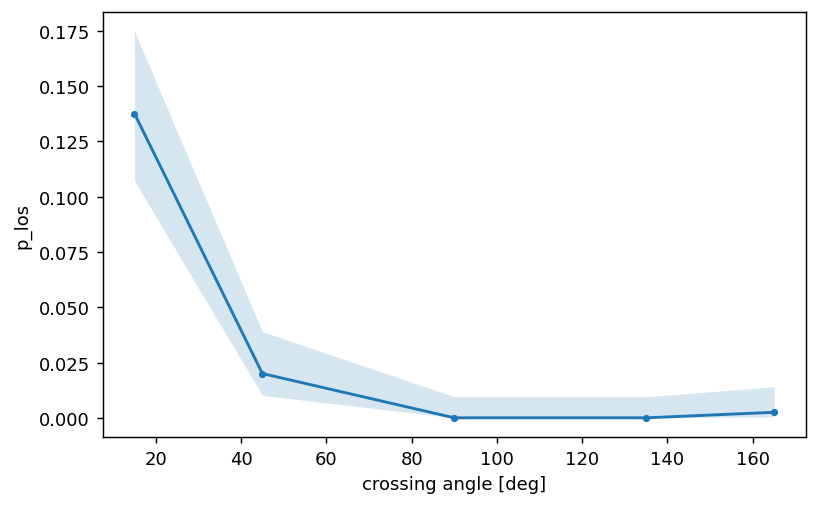

In [4]:
fig = angles.plot(metric="p_los")     # returns the Figure, so it can be saved or tweaked
fig.axes[0].set_xlabel("crossing angle [deg]")
fig.tight_layout()

The shallow crossing is the hardest, by a wide margin — which is the documented result, and the
one that is easy to get backwards. At a shallow angle the *relative* velocity is a small difference
of two large ones, so the closest approach is dominated by measurement error rather than by
geometry. A loop that quietly averages that noise away makes 15° look like the easiest case
instead of the hardest (`vault/observations/near-parallel-ipr-inversion.md`).

`{"dpsi": Sweep([...])}` still works too and means exactly the same thing — the geometry slots are
kept as sugar over `PairwiseEncounter`. What is *not* allowed is declaring `dpsi` against a
scenario that has no such parameter; that fails at declaration rather than being quietly dropped:

In [5]:
try:
    run_experiment({"dpsi": Fixed(90.0), "scenario": Fixed(CrossingRing(3))},
                   methods=STACK, backend=MC(n_encounters=10), base_config=CFG)
except ValueError as exc:
    print(f"refused: {exc}")

refused: the geometry slots ['dpsi'] only apply to a PairwiseEncounter, but this condition declares CrossingRing. Put the geometry in the scenario itself — e.g. Sweep([...], build=lambda v: CrossingRing(...)).


## 2 — the ring

The same declaration, a different scenario. Nothing else moves: same stack, same backend type,
same reporting. The ring is deterministic, so every encounter in a cell is the *same* geometry and
the spread between them is the fix accuracy alone.

In [6]:
ring = run_experiment(
    {"scenario": Sweep([2, 3, 4], name="n_aircraft",
                       build=lambda n: CrossingRing(n, radius=500.0))},
    methods=STACK, backend=MC(n_encounters=400), base_config=CFG, seed=1,
)

for row in ring.records():
    print(f"N = {row['n_aircraft']}   P(LoS) = {row['p_los']:.4f}   "
          f"median closest approach {row['median_min_sep']:6.1f} m")

N = 2   P(LoS) = 0.0000   median closest approach   69.2 m
N = 3   P(LoS) = 0.0000   median closest approach   66.6 m
N = 4   P(LoS) = 0.0000   median closest approach   64.6 m


## 3 — random traffic

Traffic drawn by the entry rule of Groot, Ellerbroek and Hoekstra (2024): random headings, entry
offsets uniform across the diameter, released on an outer circle and measured inside an inner one.

The measured disc travels **with the scenario** — `RandomTraffic.measurement_area()` returns it —
so it cannot be declared inconsistently with the geometry it belongs to.

In [7]:
traffic = run_experiment(
    {"scenario": Sweep([4, 6, 8], name="n_aircraft",
                       build=lambda n: RandomTraffic(n, r_inner=1000.0, r_outer=1200.0))},
    methods=STACK, backend=MC(n_encounters=400), base_config=CFG, seed=1,
)

for row in traffic.records():
    print(f"N = {row['n_aircraft']}   P(LoS) = {row['p_los']:.4f}   "
          f"median closest approach {row['median_min_sep']:6.1f} m   "
          f"detected {row['detection_rate']:.2f}")

N = 4   P(LoS) = 0.0000   median closest approach  107.5 m   detected 0.47
N = 6   P(LoS) = 0.0000   median closest approach   73.6 m   detected 0.84
N = 8   P(LoS) = 0.0000   median closest approach   67.0 m   detected 0.96


Most of these read zero, which is the honest answer at 400 encounters and the reason the
rare-event backend exists.

## Swapping the backend

`MC` and `IPS` are interchangeable in the same declaration. The one thing IPS needs that MC does
not is a **shell ladder**, and the right ladder differs per condition — the shells that suit a
two-aircraft ring collapse on an eight-aircraft disc. `Ladder` runs a short pilot per condition and
places the shells on that cell's own minimum-separation record.

This cell keeps the poor fix, and not to make the plot look better: 300 particles is a *small*
population, and at the 10 m fix the rest of the notebook uses it is not enough — running this at
that accuracy collapses three replications in four. Which is the point of the next paragraph.

In [8]:
rare = run_experiment(
    {"pos_ci95": Fixed(40.0), "vel_ci95": Fixed(3.0),          # the poor fix again, see below
     "recovery": Fixed(PastCPA(bouncing_guard=True)),
     "scenario": Sweep([3, 4], name="n_aircraft",
                       build=lambda n: CrossingRing(n, radius=500.0))},
    methods=STACK,
    backend=IPS(shells=Ladder(pilot=400, step=1.0), n_particles=300, reps=4),
    base_config=CFG, seed=1,
)

for row, est in zip(rare.records(), rare.results, strict=True):
    shells = est.reps[0].levels
    print(f"N = {row['n_aircraft']}   P(LoS) = {row['p_los']:.2e}   "
          f"95% CI [{row['p_los_lo']:.1e}, {row['p_los_hi']:.1e}]   "
          f"collapsed {row['n_collapsed']}/{row['reps']}   {len(shells)} shells "
          f"({shells[0]:.0f} -> {shells[-1]:.0f} m)")

N = 3   P(LoS) = 6.03e-03   95% CI [1.3e-03, 1.1e-02]   collapsed 0/4   33 shells (105 -> 50 m)
N = 4   P(LoS) = 2.30e-02   95% CI [2.0e-02, 2.6e-02]   collapsed 0/4   23 shells (88 -> 50 m)


Each cell got its own ladder, derived from its own pilot, and the ladder used is reported back so
the run stays reproducible after the fact.

**Read `collapsed` before reading the probability.** A replication collapses when some shell ends
with no survivors; it returns zero, and that zero is a failed run rather than a small number. Any
non-zero count means the ladder was too aggressive or the population too small for the rarity, and
the fix is more particles or a finer `step` — never a re-seed, because the product estimator is
unbiased only when collapses are counted rather than dropped.

## Comparing methods across scenarios

This is what the whole arrangement is for. Scenario and methods are independent axes, so a
cross-product is one declaration — and because the caching is per condition, extending it later
re-runs only the new cells.

In [9]:
grid = run_experiment(
    {"scenario": Sweep([PairwiseEncounter(dpsi=90.0), CrossingRing(4), RandomTraffic(4)],
                       name="scenario"),
     "resolver": Sweep([MVP(1.05), VO(1.05)], name="resolver")},
    methods=STACK, backend=MC(n_encounters=300), base_config=CFG, seed=2,
)

frame = {}
for row in grid.records():
    frame.setdefault(type(row["scenario"]).__name__, {})[type(row["resolver"]).__name__] = (
        row["p_los"], row["median_min_sep"])

print(f"{'scenario':<20}  {'MVP':>22}  {'VO':>22}")
for name, by_resolver in frame.items():
    cells = "  ".join(f"{p:.3f} / {d:6.1f} m" for p, d in
                      (by_resolver[r] for r in ("MVP", "VO")))
    print(f"{name:<20}  {cells}")
print("\n(P(LoS) / median closest approach)")

scenario                                 MVP                      VO
PairwiseEncounter     0.000 /   75.9 m  0.000 /   76.0 m
CrossingRing          0.000 /   64.3 m  0.003 /   65.1 m
RandomTraffic         0.000 /  101.5 m  0.017 /   98.5 m

(P(LoS) / median closest approach)


Six conditions, one table. The resolver comparison means something different in each row — a fixed
90° crossing, an arranged four-aircraft worst case, and four drones on random headings — and
nothing about the declaration changed between them except which scenario object went in.

## What flies the scenario

A scenario returns states, not aircraft. It never selects the airframe — that is `Methods`, through
`perf`/`kinematics` for a uniform fleet or `airframes` for a mixed one, with one `Airframe` per
aircraft in fleet order. So the same ring can be flown by eight multirotors, or by a mix of
multirotors, fixed-wings and something you built yourself, and the geometry code is untouched.

Speed is where that neutrality meets a hard limit, because each envelope has its own range:

In [10]:
from opencdarr import SMALL_FIXEDWING, Airframe
from opencdarr.kinematics import FixedWing, Multirotor

MY_QUAD = dataclasses.replace(M600, v_max=14.0, v_min=-14.0, yaw_rate_max=120.0)

for name, perf in (("M600", M600), ("SMALL_FIXEDWING", SMALL_FIXEDWING), ("MY_QUAD", MY_QUAD)):
    print(f"{name:<16} {perf.v_min:6.1f} to {perf.v_max:5.1f} m/s")

mix = ([Airframe(M600, Multirotor())] * 3              # stock multirotor
       + [Airframe(SMALL_FIXEDWING, FixedWing())] * 3  # stock fixed-wing
       + [Airframe(MY_QUAD, Multirotor())] * 2)        # one you built: a Performance value

M600              -18.0 to  18.0 m/s
SMALL_FIXEDWING    12.0 to  25.0 m/s
MY_QUAD           -14.0 to  14.0 m/s


The fixed-wing stalls below 12 m/s. So 10 m/s — the normal multirotor cruise the rest of this
notebook uses — is not a speed all three can fly, and `Agent` refuses it rather than flying an
aircraft outside its own envelope:

In [11]:
try:
    run_experiment({"scenario": Fixed(CrossingRing(8, radius=1500.0))},
                   methods=dataclasses.replace(STACK, airframes=mix, perf=None),
                   backend=MC(n_encounters=4), base_config=CFG)
except ValueError as exc:
    print(f"refused: {exc}")

refused: initial ground speed 10.0 m/s for 'A3' is outside its envelope [12.0, 25.0] m/s. In a mixed fleet, set each aircraft's speed for its own airframe (the sampler's `speed` / `gs_intr`).


Choosing a speed inside every envelope would work — 12 to 14 m/s is the overlap — but it would fly
the multirotors 40% above their normal cruise only to keep the fixed-wing airborne. Give each
aircraft its own speed instead. Every fleet builder takes `speed: float | Sequence[float]`, and the
scenario classes carry it as `speeds`:

In [12]:
mixed_ring = CrossingRing(8, radius=1500.0,
                          speeds=(10.0,) * 3 + (20.0,) * 3 + (12.0,) * 2)

fleet = mixed_ring.draw(np.random.default_rng(0), CFG)
for k in (0, 3, 6):
    print(f"A{k}   {fleet[k][0].gs:5.1f} m/s   {type(mix[k].kinematics).__name__}")

mixed = run_experiment(
    {"scenario": Fixed(mixed_ring)},
    methods=dataclasses.replace(STACK, airframes=mix, perf=None),
    backend=MC(n_encounters=100), base_config=CFG, seed=4,
)
row = mixed.records()[0]
print()
print(f"8 aircraft, 3 types, 3 speeds:  P(LoS) = {row['p_los']:.3f}   "
      f"median closest approach {row['median_min_sep']:.1f} m")

A0    10.0 m/s   Multirotor
A3    20.0 m/s   FixedWing
A6    12.0 m/s   Multirotor



8 aircraft, 3 types, 3 speeds:  P(LoS) = 0.000   median closest approach 59.1 m


A speed list of the wrong length fails at the call rather than silently reusing the last value, the
same way a wrong-length `airframes` list does.

One behaviour to know before mixing in a fixed-wing: **it does not stop at its final waypoint, it
orbits it** at the loiter radius, 80 m by default. Its distance to the goal never falls below that,
so `stop_within=50` never counts it as arrived and the run continues to `t_max`. Set `stop_within`
to at least the loiter radius when a fixed-wing must register as finished.

## Build your own scenario

A scenario is a contribution surface: implement `draw` and everything above works unchanged. Here
is a complete one — an **overtaking** encounter, where a faster aircraft comes up behind a slower
one on nearly the same heading. It is a case worth having, because slow closure means a long time
to CPA and a miss distance dominated by navigation error rather than by geometry.

In [13]:
from dataclasses import dataclass

from opencdarr import Scenario
from opencdarr.geo import forward
from opencdarr.state import AircraftState


@dataclass(frozen=True)
class Overtaking(Scenario):
    """A faster aircraft closing from behind on a nearly parallel track.

    `lead_speed_ratio` is how slow the aircraft in front is; `offset` is the lateral separation of
    the two tracks, so `offset < rpz` is a genuine conflict. The heading difference is small on
    purpose -- this is the geometry where the relative velocity is a small difference of two large
    numbers, and the closest approach is therefore hard to predict.

    The pair is placed so the overtake happens `time_to_pass` seconds in whatever the speeds are.
    """

    lead_speed_ratio: float = 0.6
    offset: float = 30.0
    dpsi: float = 3.0
    time_to_pass: float = 200.0

    def draw(self, rng, config):
        speed = config.scenario.speed
        acc = dict(pos_ci95=config.scenario.pos_ci95, vel_ci95=config.scenario.vel_ci95)

        if not 0.0 < self.lead_speed_ratio < 1.0:
            raise ValueError("lead_speed_ratio must be in (0, 1) for anyone to overtake anyone")
        lead_speed = speed * self.lead_speed_ratio
        lead = AircraftState(id="LEAD", lat=52.0, lon=4.0, trk=0.0, gs=lead_speed, **acc)
        # Start them the distance the *closing speed* covers in time_to_pass, not a fixed gap:
        # specify the encounter by when it happens, the way create_conflict takes a tlos. A fixed
        # gap would mean the slowest closure never completes inside t_max, and the trend you
        # measured would be the truncation rather than the geometry.
        behind = forward(lead.lat, lead.lon, 180.0, self.time_to_pass * (speed - lead_speed))
        start = forward(behind[0], behind[1], 90.0, self.offset)
        follow = AircraftState(id="FOLLOW", lat=start[0], lon=start[1],
                               trk=(-self.dpsi) % 360.0, gs=speed, **acc)

        # No goal: each holds the cruise it was given. That matters here, because the whole
        # geometry is a *speed difference* -- and a multirotor handed a waypoint chases a position
        # setpoint at whatever its envelope allows (18 m/s for a stock M600), which would quietly
        # erase the difference. Give a goal when the mission is the point; hold cruise when the
        # geometry is.
        return [(lead, None), (follow, None)]

    def size(self):
        return 2


from opencdarr.geo import qdrdist

fleet = Overtaking().draw(np.random.default_rng(0), CFG)
for state, goal in fleet:
    print(f"{state.id:<7} trk {state.trk:6.1f} deg   gs {state.gs:5.1f} m/s   "
          f"goal: {'hold cruise' if goal is None else goal}")

(lead, _), (follow, _) = fleet
_, apart = qdrdist(lead.lat, lead.lon, follow.lat, follow.lon)
print()
print(f"starting {apart:.0f} m apart, closing at {follow.gs - lead.gs:.1f} m/s")

LEAD    trk    0.0 deg   gs   6.0 m/s   goal: hold cruise
FOLLOW  trk  357.0 deg   gs  10.0 m/s   goal: hold cruise

starting 801 m apart, closing at 4.0 m/s


That is the whole implementation. It now works in every declaration above — swept, compared
against other scenarios, and run through either backend:

In [14]:
own = run_experiment(
    {"scenario": Sweep([0.5, 0.7, 0.9], name="lead_speed_ratio",
                       build=lambda r: Overtaking(lead_speed_ratio=r))},
    methods=STACK, backend=MC(n_encounters=300), base_config=CFG, seed=3,
)

for row in own.records():
    print(f"lead at {row['lead_speed_ratio']:.0%} of cruise   P(LoS) = {row['p_los']:.3f}   "
          f"median closest approach {row['median_min_sep']:6.1f} m   "
          f"detected {row['detection_rate']:.2f}")

lead at 50% of cruise   P(LoS) = 0.000   median closest approach   75.9 m   detected 0.11
lead at 70% of cruise   P(LoS) = 0.003   median closest approach   78.3 m   detected 0.16
lead at 90% of cruise   P(LoS) = 0.000   median closest approach   76.3 m   detected 0.19


The closest approach barely moves across the three — all within a couple of metres — but the
detector fires roughly twice as often as the speeds converge. With less relative velocity the pair
spends far longer inside the fixed lookahead horizon, so there is much more opportunity for the
extrapolation to flag it, even though the encounter itself is no tighter.

## What to reach for

- **`PairwiseEncounter`** when the question is about a geometry — a response curve over crossing
  angle, miss distance or speed ratio.
- **`CrossingRing`** when the question is about an arranged worst case, and you want the noise to
  be the only thing varying.
- **`RandomTraffic`** when the question is about a *distribution* of arrangements, which is what a
  density-based safety argument needs.
- **your own** when none of those is the airspace you care about. One method.

Two limits worth knowing. A scenario is a **fixed roster** — aircraft cannot join or leave
mid-run, so an open traffic *stream* is not expressible yet
(`vault/future-features/mid-run-arrivals.md`). And a scenario declares `supports_splitting()`:
a future stream would return `False`, because over hours of arrivals "at least one loss" stops
being rare and the running minimum stops discriminating between particles, so IPS would spend a
great deal of compute to return a number near 1. Better to refuse that combination at declaration
time than to discover it afterwards.